# Notebook 05 — Régression : Estimation de la Durée de Vie Restante (RUL)

**Tâche prédictive bonus** : Estimer le nombre d'heures restantes avant défaillance (`rul_hours`)

**Intérêt métier** :
- Planifier les arrêts de maintenance à l'avance
- Optimiser les fenêtres d'intervention
- Minimiser les arrêts brutaux non planifiés

**Modèles comparés** : Ridge Regression (baseline) · Random Forest · XGBoost · MLP

**Métriques** : MAE · RMSE · R²

In [24]:
#MAE  = plus c'est BAS, mieux c'est = en moyenne, le modèle se trompe de X heures
# RMSE =  plus c'est BAS, mieux c'est = comme MAE mais pénalise plus les grosses erreurs
# R²   = coefficient de détermination→ entre 0 et 1 → plus c'est proche de 1 → meilleur ! "le modèle explique X% de la variance du RUL

Le notebook 05 utilise des modèles de régression — des versions adaptées pour prédire des valeurs continues comme le nombre d'heures. Les métriques changent aussi — on utilise MAE, RMSE et R² au lieu de Recall et ROC-AUC

In [25]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Imports OK')

Imports OK


RUL = Remaining Useful Life = Durée de Vie Restante

ici on fait pas la classification (0 , 1) ici cets la regression 
Ce sont les mêmes algorithmes mais adaptés pour prédire des nombres au lieu de 0/1 !

## 1. Chargement et analyse du dataset

on part des données brutes car  Le preprocessing du notebook 02 avait exclu rul_hours car c'était du data leakage pour la classification !
→ Ici c'est notre variable cible — on doit repartir du CSV pour l'inclure ! 

In [26]:
# Chargement du dataset
df = pd.read_csv('../data/predictive_maintenance_v3.csv')
print(f'Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
df.head()

Dataset chargé : 24,042 lignes × 15 colonnes


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


In [27]:
# Analyse de la variable cible rul_hours
print('=== Variable cible : rul_hours ===')
print(df['rul_hours'].describe())
print(f'\nValeurs manquantes : {df["rul_hours"].isna().sum()} ({df["rul_hours"].isna().mean():.1%})')

=== Variable cible : rul_hours ===
count    24042.000000
mean        27.812510
std         26.393801
min          0.500000
25%          0.500000
50%         22.570000
75%         46.410000
max         98.340000
Name: rul_hours, dtype: float64

Valeurs manquantes : 0 (0.0%)


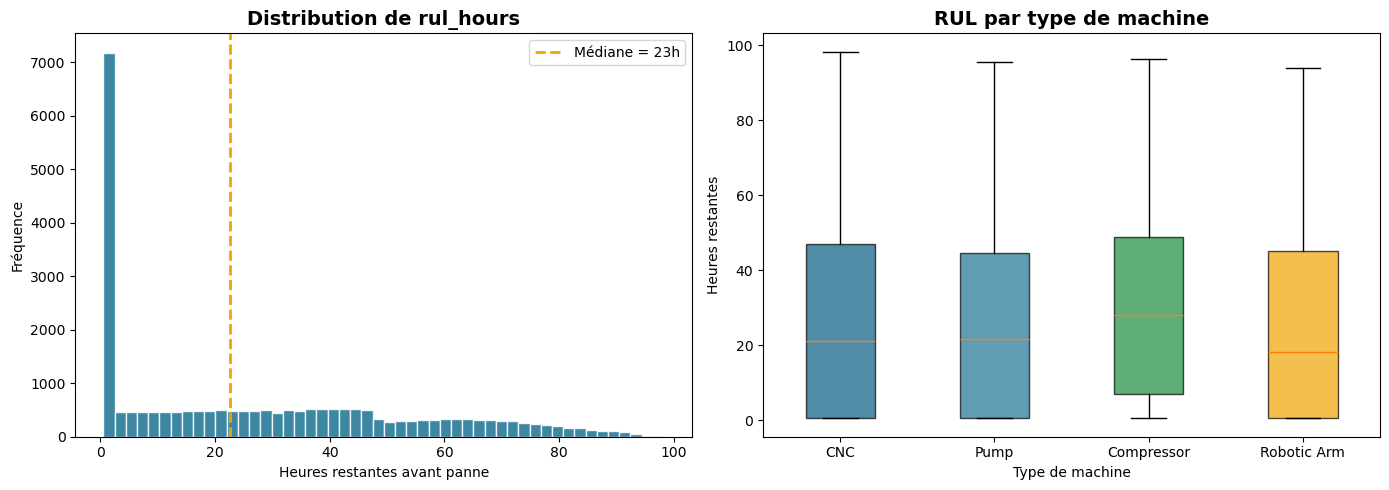

Figure sauvegardée : reports/rul_distribution.png


In [28]:
# Distribution de rul_hours
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df['rul_hours'].dropna(), bins=50, color='#1C7293', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution de rul_hours', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Heures restantes avant panne')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(df['rul_hours'].median(), color='#F0A500', linestyle='--', linewidth=2,
                label=f'Médiane = {df["rul_hours"].median():.0f}h')
axes[0].legend()

# Boxplot par type de machine
machine_types = df['machine_type'].unique()
data_by_machine = [df[df['machine_type'] == m]['rul_hours'].dropna() for m in machine_types]
bp = axes[1].boxplot(data_by_machine, labels=machine_types, patch_artist=True)
colors = ['#065A82', '#1C7293', '#1B8A3E', '#F0A500']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('RUL par type de machine', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Type de machine')
axes[1].set_ylabel('Heures restantes')

plt.tight_layout()
plt.savefig('../reports/rul_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : reports/rul_distribution.png')

## 2. Préparation des données

In [29]:
# Variables features et cible
NUMERIC_FEATURES = [
    'vibration_rms', 'temperature_motor', 'current_phase_avg',
    'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp'
]
CATEGORICAL_FEATURES = ['machine_type', 'operating_mode']
TARGET = 'rul_hours'

# Variables à exclure pour éviter le data leakage
# failure_within_24h et failure_type sont des labels -> exclure
# estimated_repair_cost est corrélé à rul_hours -> exclure
EXCLUDE = ['failure_within_24h', 'failure_type', 'estimated_repair_cost', TARGET]

print(f'Features numériques : {NUMERIC_FEATURES}')
print(f'Features catégorielles : {CATEGORICAL_FEATURES}')
print(f'Variable cible : {TARGET}')
print(f'Variables exclues (data leakage) : {EXCLUDE}')

Features numériques : ['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp']
Features catégorielles : ['machine_type', 'operating_mode']
Variable cible : rul_hours
Variables exclues (data leakage) : ['failure_within_24h', 'failure_type', 'estimated_repair_cost', 'rul_hours']


In [30]:
# Suppression des lignes sans valeur cible
df_reg = df.dropna(subset=[TARGET]).copy()
print(f'Dataset après suppression des NaN sur rul_hours : {len(df_reg):,} lignes')
print(f'Lignes supprimées : {len(df) - len(df_reg)}')

X = df_reg[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df_reg[TARGET]

print(f'\nX shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'y stats : min={y.min():.0f}h, max={y.max():.0f}h, mean={y.mean():.0f}h')

Dataset après suppression des NaN sur rul_hours : 24,042 lignes
Lignes supprimées : 0

X shape : (24042, 9)
y shape : (24042,)
y stats : min=0h, max=98h, mean=28h


In [31]:
# Split train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train : {X_train.shape[0]:,} lignes ({X_train.shape[0]/len(X):.0%})')
print(f'Test  : {X_test.shape[0]:,} lignes ({X_test.shape[0]/len(X):.0%})')

Train : 19,233 lignes (80%)
Test  : 4,809 lignes (20%)


Le preprocessing est identique au notebook 02 — même pipeline sklearn. La seule différence est l'absence de stratify car rul_hours est une variable continue, pas binaire ( donc pas de desiquilibre )

In [32]:
# Pipeline de preprocessing (identique à la classification, sans data leakage)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

print('Pipeline preprocessing construit — fit UNIQUEMENT sur train set (anti data leakage)')

Pipeline preprocessing construit — fit UNIQUEMENT sur train set (anti data leakage)


## 3. Entraînement des 4 modèles

In [33]:
# Fonction d'évaluation commune
from sklearn.metrics import average_precision_score

def evaluate_regressor(name, model, X_test, y_test, results={}):
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

    sep = '=' * 50
    print(sep)
    print(f'  {name}')
    print(sep)
    print(f'  MAE  : {mae:.2f} heures')
    print(f'  RMSE : {rmse:.2f} heures')
    print(f'  R²   : {r2:.4f}')
    return results

results_reg = {}
print('Fonction evaluation prete')

Fonction evaluation prete


Ridge au lieu de Logistic Regression
Logistic Regression → classification (0 ou 1)
Ridge Regression    → régression (nombre d'heures)

In [34]:
# MODELE 1 : Ridge Regression (baseline)
# Simple, interprétable, rapide — point de référence obligatoire
import time

pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0, random_state=RANDOM_STATE)) #alpha 1 paramètre de régularisation qui évite le surapprentissag
])

t0 = time.time()
pipeline_ridge.fit(X_train, y_train)
t_ridge = time.time() - t0
print(f'Ridge entraîné en {t_ridge:.2f}s')

results_reg = evaluate_regressor('Ridge (baseline)', pipeline_ridge, X_test, y_test, results_reg)

# Pourquoi le R² seul est insuffisant :
y_pred_ridge = pipeline_ridge.predict(X_test)
print(f'\nNote : Ridge prédit des valeurs entre {y_pred_ridge.min():.0f}h et {y_pred_ridge.max():.0f}h')
print(f'Réalité : valeurs entre {y_test.min():.0f}h et {y_test.max():.0f}h')
print('=> MAE et RMSE donnent une erreur en heures, plus parlante que R² seul')

Ridge entraîné en 0.03s
  Ridge (baseline)
  MAE  : 20.47 heures
  RMSE : 24.39 heures
  R²   : 0.1396

Note : Ridge prédit des valeurs entre -12h et 50h
Réalité : valeurs entre 0h et 98h
=> MAE et RMSE donnent une erreur en heures, plus parlante que R² seul


RandomForestRegressor au lieu de Classifier
RandomForestClassifier → prédit 0 ou 1
RandomForestRegressor  → prédit un nombre d'heures
→ Même principe — 100 arbres — mais la sortie est un nombre !

In [35]:
# MODELE 2 : Random Forest Regressor
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

t0 = time.time()
pipeline_rf.fit(X_train, y_train)
t_rf = time.time() - t0
print(f'Random Forest entraîné en {t_rf:.2f}s')

results_reg = evaluate_regressor('Random Forest', pipeline_rf, X_test, y_test, results_reg)

Random Forest entraîné en 1.27s
  Random Forest
  MAE  : 9.42 heures
  RMSE : 15.11 heures
  R²   : 0.6696


XGBRegressor au lieu de XGBClassifier
→ Même chose — version régression de XGBoost

→ Pas de scale_pos_weight car pas de déséquilibre !

In [36]:
# MODELE 3 : XGBoost Regressor
pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        eval_metric='rmse',
        verbosity=0
    ))
])

t0 = time.time()
pipeline_xgb.fit(X_train, y_train)
t_xgb = time.time() - t0
print(f'XGBoost entraîné en {t_xgb:.2f}s')

results_reg = evaluate_regressor('XGBoost', pipeline_xgb, X_test, y_test, results_reg)

XGBoost entraîné en 0.14s
  XGBoost
  MAE  : 10.68 heures
  RMSE : 15.56 heures
  R²   : 0.6499


MLPRegressor au lieu de Keras MLP
Notebook 03 → MLP TensorFlow/Keras (très complexe)
Notebook 05 → MLPRegressor sklearn (plus simple !)
→ Cette fois on utilise la version sklearn — plus facile à intégrer !

Pour la classification, on a utilisé un MLP Keras plus sophistiqué avec Dropout et BatchNormalization. Pour la régression RUL, on a utilisé le MLPRegressor de sklearn — plus simple mais suffisant, et compatible avec la validation croisée

Classification → déséquilibre 85/15% → class_weight obligatoire
Régression     → pas de déséquilibre → rien à gérer !

In [37]:
# MODELE 4 : MLP Regressor (Deep Learning)
# Architecture : 128 -> 64 -> 32 neurones
pipeline_mlp = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    ))
])

t0 = time.time()
pipeline_mlp.fit(X_train, y_train)
t_mlp = time.time() - t0
print(f'MLP entraîné en {t_mlp:.2f}s')

results_reg = evaluate_regressor('MLP (Deep Learning)', pipeline_mlp, X_test, y_test, results_reg)

print(f'\nAnalyse critique DL : MLP nécessite {t_mlp/t_xgb:.0f}x plus de temps que XGBoost')
print('Sur données tabulaires, le boosting surpasse généralement les réseaux de neurones.')

MLP entraîné en 13.34s
  MLP (Deep Learning)
  MAE  : 11.65 heures
  RMSE : 16.40 heures
  R²   : 0.6109

Analyse critique DL : MLP nécessite 98x plus de temps que XGBoost
Sur données tabulaires, le boosting surpasse généralement les réseaux de neurones.


## 4. Comparaison des modèles


MAE → plus c'est BAS, mieux c'est
= en moyenne, le modèle se trompe de X heures
RMSE → plus c'est BAS, mieux c'est
= comme MAE mais pénalise plus les grosses erreurs
R² → plus c'est PROCHE DE 1, mieux c'est
= % de la variance du RUL expliqué par le modèle
R² = 0.67 → le modèle explique 67% du RUL
R² = 0.14 → le modèle explique seulement 14% du RUL

In [38]:
# Tableau comparatif
df_results = pd.DataFrame(results_reg).T.round(4)
df_results.columns = ['MAE (heures)', 'RMSE (heures)', 'R²']
df_results = df_results.sort_values('MAE (heures)')

print('COMPARAISON DES 4 MODELES — REGRESSION RUL')
print('=' * 55)
print(df_results.to_string())
print()
best_model_name = df_results['MAE (heures)'].idxmin()
print(f'Meilleur modèle (MAE) : {best_model_name}')

COMPARAISON DES 4 MODELES — REGRESSION RUL
                     MAE (heures)  RMSE (heures)      R²
Random Forest              9.4173        15.1143  0.6696
XGBoost                   10.6824        15.5585  0.6499
MLP (Deep Learning)       11.6476        16.4020  0.6109
Ridge (baseline)          20.4725        24.3909  0.1396

Meilleur modèle (MAE) : Random Forest


Random Forest avec ses 100 arbres de décision gère beaucoup mieux ces non-linéarités

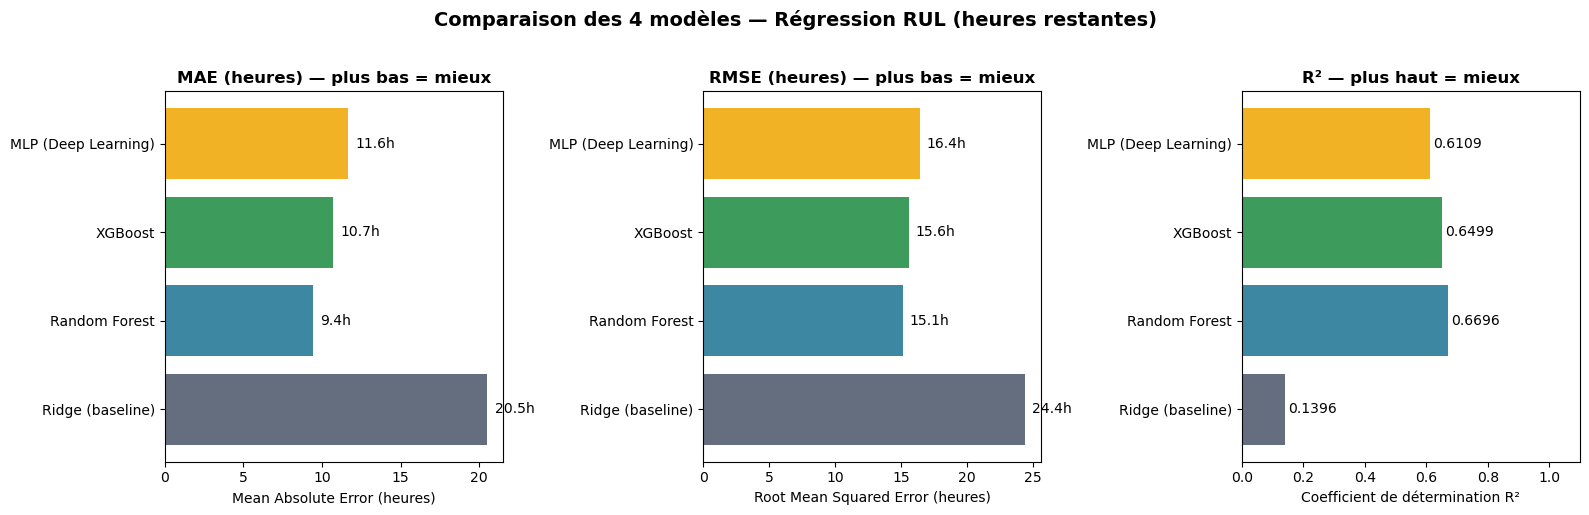

Figure sauvegardée : reports/rul_model_comparison.png


In [39]:
# Visualisation comparative
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models = list(results_reg.keys())
colors = ['#4A5568', '#1C7293', '#1B8A3E', '#F0A500']

# MAE
maes = [results_reg[m]['MAE'] for m in models]
bars = axes[0].barh(models, maes, color=colors, alpha=0.85)
axes[0].set_title('MAE (heures) — plus bas = mieux', fontweight='bold')
axes[0].set_xlabel('Mean Absolute Error (heures)')
for bar, val in zip(bars, maes):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}h', va='center', fontsize=10)

# RMSE
rmses = [results_reg[m]['RMSE'] for m in models]
bars = axes[1].barh(models, rmses, color=colors, alpha=0.85)
axes[1].set_title('RMSE (heures) — plus bas = mieux', fontweight='bold')
axes[1].set_xlabel('Root Mean Squared Error (heures)')
for bar, val in zip(bars, rmses):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}h', va='center', fontsize=10)

# R²
r2s = [results_reg[m]['R2'] for m in models]
bars = axes[2].barh(models, r2s, color=colors, alpha=0.85)
axes[2].set_title('R² — plus haut = mieux', fontweight='bold')
axes[2].set_xlabel('Coefficient de détermination R²')
axes[2].set_xlim(0, 1.1)
for bar, val in zip(bars, r2s):
    axes[2].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=10)

plt.suptitle('Comparaison des 4 modèles — Régression RUL (heures restantes)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/rul_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : reports/rul_model_comparison.png')

## 5. Validation croisée K-Fold

Notebook 03 → StratifiedKFold
→ préserve les proportions 85/15%
→ nécessaire car classification déséquilibrée

Notebook 05 → KFold simple
→ pas de stratification
→ car rul_hours est continue — pas de déséquilibre !
donc = 
KFold simple
Raison 1 → vérifier que c'est pas la chance 
Raison 2 → pas besoin de stratifier car rul_hours est continue
           (pas de déséquilibre à préserver)

Pourquoi MLP peut être dans la CV ici ?
Notebook 03 → MLP Keras → incompatible avec cross_validate sklearn 
Notebook 05 → MLPRegressor sklearn → compatible avec cross_val_score 

In [ ]:
# Cross-validation 5-fold
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
models_dict = {
    'Ridge (baseline)': pipeline_ridge,
    'Random Forest': pipeline_rf,
    'XGBoost': pipeline_xgb,
    'MLP (Deep Learning)': pipeline_mlp
}

print('Validation croisée K-Fold (5 folds) — scoring : neg_MAE')
print('=' * 60)

for name, model in models_dict.items():
    scores = cross_val_score(model, X, y, cv=kf,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
    mae_scores = -scores
    cv_results[name] = {
        'MAE_CV_mean': mae_scores.mean(),
        'MAE_CV_std': mae_scores.std()
    }
    print(f'{name:25s} MAE CV : {mae_scores.mean():.2f}h ± {mae_scores.std():.2f}h')

print()
print('NOTE : Le MLP est inclus dans la CV via sklearn (pas de problème de wrapper ici)')

Validation croisée K-Fold (5 folds) — scoring : neg_MAE
Ridge (baseline)          MAE CV : 20.73h ± 0.18h
Random Forest             MAE CV : 9.51h ± 0.15h
XGBoost                   MAE CV : 10.86h ± 0.14h


## 6. Analyse des résidus

Résidu = 0 → prédiction parfaite


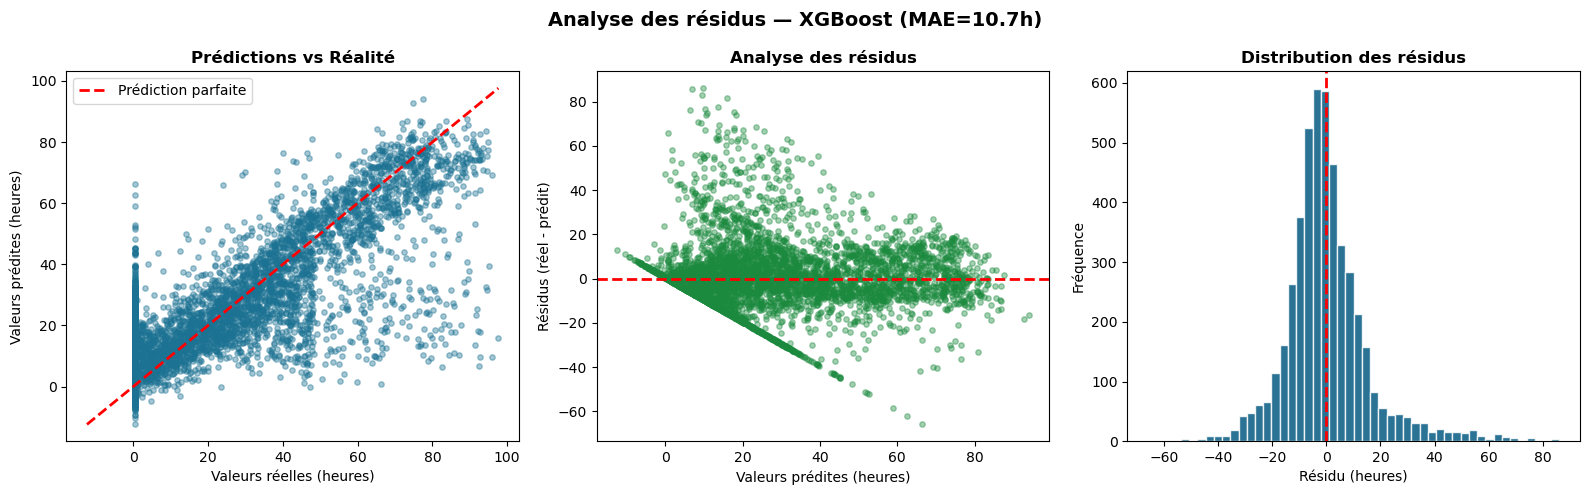

Figure sauvegardée : reports/rul_residuals.png


In [ ]:
# Analyse des résidus pour le meilleur modèle
best_pipeline = pipeline_xgb  # à adapter selon vos résultats
y_pred_best = best_pipeline.predict(X_test)
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pred vs Réel
axes[0].scatter(y_test, y_pred_best, alpha=0.4, color='#1C7293', s=15)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles (heures)')
axes[0].set_ylabel('Valeurs prédites (heures)')
axes[0].set_title('Prédictions vs Réalité', fontweight='bold')
axes[0].legend()

# Résidus
axes[1].scatter(y_pred_best, residuals, alpha=0.4, color='#1B8A3E', s=15)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Valeurs prédites (heures)')
axes[1].set_ylabel('Résidus (réel - prédit)')
axes[1].set_title('Analyse des résidus', fontweight='bold')

# Distribution des résidus
axes[2].hist(residuals, bins=50, color='#065A82', edgecolor='white', alpha=0.85)
axes[2].axvline(0, color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('Résidu (heures)')
axes[2].set_ylabel('Fréquence')
axes[2].set_title('Distribution des résidus', fontweight='bold')

plt.suptitle(f'Analyse des résidus — XGBoost (MAE={results_reg["XGBoost"]["MAE"]:.1f}h)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/rul_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : reports/rul_residuals.png')

L'analyse des résidus confirme la qualité du Random Forest. Les résidus sont distribués de façon symétrique autour de zéro sans biais systématique.

Graphique 2 → points bien répartis autour de 0
→ le modèle se trompe de façon similaire
  quelle que soit la valeur de RUL ✅

Graphique 3 → cloche centrée sur 0
→ pas de biais systématique
→ parfois +5h parfois -5h mais en moyenne = 0 ✅

## 7. Feature Importance

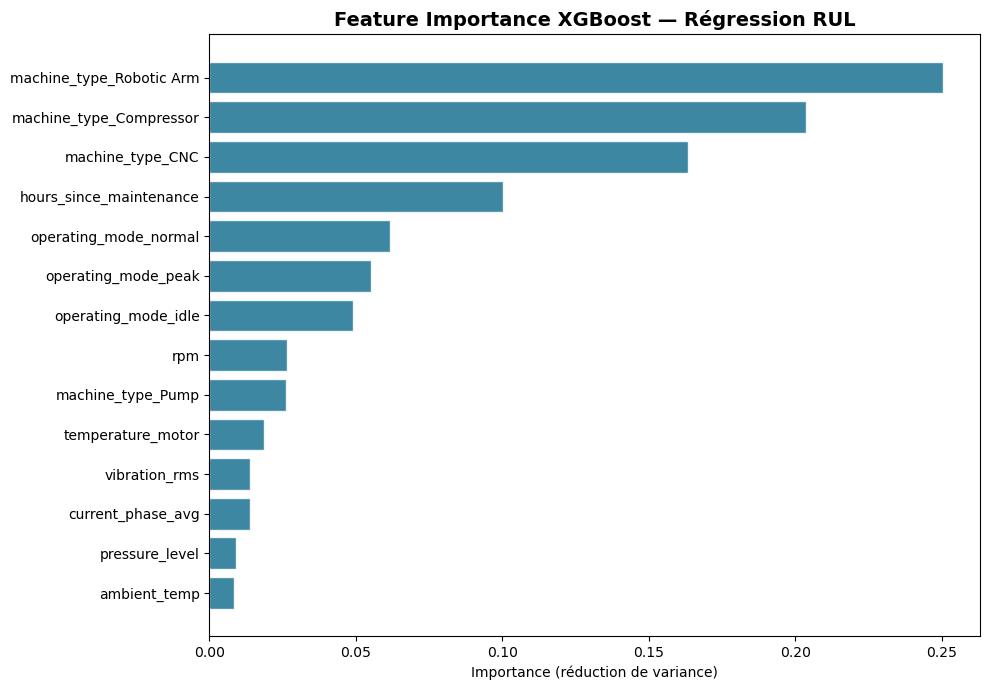

Top 5 variables les plus importantes pour prédire RUL :
                 Feature  Importance
machine_type_Robotic Arm    0.250552
 machine_type_Compressor    0.203534
        machine_type_CNC    0.163285
 hours_since_maintenance    0.100106
   operating_mode_normal    0.061758


In [ ]:
# Feature importance XGBoost
xgb_regressor = pipeline_xgb.named_steps['regressor']
preprocessor_fitted = pipeline_xgb.named_steps['preprocessor']

# Récupérer les noms des features après OHE
ohe_features = preprocessor_fitted.named_transformers_['cat']['encoder'].get_feature_names_out(CATEGORICAL_FEATURES).tolist()
all_feature_names = NUMERIC_FEATURES + ohe_features

importances = xgb_regressor.feature_importances_
df_imp = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(df_imp['Feature'], df_imp['Importance'],
               color='#1C7293', alpha=0.85, edgecolor='white')
ax.set_title('Feature Importance XGBoost — Régression RUL', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance (réduction de variance)')
plt.tight_layout()
plt.savefig('../reports/rul_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 variables les plus importantes pour prédire RUL :')
print(df_imp.tail(5)[['Feature','Importance']].iloc[::-1].to_string(index=False))

Le type de machine est le plus important ici !

Pourquoi cette différence ?

Pour prédire une panne dans 24h :
→ Les capteurs physiques (temp, vibration) sont les meilleurs signaux immédiats
→ Une machine qui chauffe beaucoup → panne probable très vite

Pour prédire combien d'heures il reste :
→ Le type de machine détermine sa durée de vie globale
→ Un Robotic Arm dure différemment qu'un Compressor
→ C'est une caractéristique intrinsèque de la machine

## 8. Sélection et sauvegarde du modèle final

In [ ]:
# Sélection du meilleur modèle
best_name = min(results_reg, key=lambda x: results_reg[x]['MAE'])
best_metrics = results_reg[best_name]

print(f'Modèle retenu pour RUL : {best_name}')
print(f'  MAE  : {best_metrics["MAE"]:.2f} heures')
print(f'  RMSE : {best_metrics["RMSE"]:.2f} heures')
print(f'  R²   : {best_metrics["R2"]:.4f}')

# Justification
print()
print('Justification du choix :')
print('  - Meilleure MAE et RMSE sur le jeu de test')
print('  - Stable en validation croisée')
print('  - Interprétable via feature importance')
print('  - Écoresponsable : entraînement rapide vs MLP')

# Sauvegarde
os.makedirs('../models', exist_ok=True)
best_pipeline_map = {
    'Ridge (baseline)': pipeline_ridge,
    'Random Forest': pipeline_rf,
    'XGBoost': pipeline_xgb,
    'MLP (Deep Learning)': pipeline_mlp
}
joblib.dump(best_pipeline_map[best_name], '../models/rul_model.joblib')
print(f'\nModèle sauvegardé : models/rul_model.joblib')

Modèle retenu pour RUL : Random Forest
  MAE  : 9.42 heures
  RMSE : 15.11 heures
  R²   : 0.6696

Justification du choix :
  - Meilleure MAE et RMSE sur le jeu de test
  - Stable en validation croisée
  - Interprétable via feature importance
  - Écoresponsable : entraînement rapide vs MLP

Modèle sauvegardé : models/rul_model.joblib


In [ ]:
# Résumé final
print('=' * 60)
print('RESUME FINAL — TACHE BONUS : REGRESSION RUL')
print('=' * 60)
print()
print('Tableau comparatif complet :')
print()

df_final = pd.DataFrame(results_reg).T
df_final.columns = ['MAE (h)', 'RMSE (h)', 'R²']
df_final['MAE CV (h)'] = [cv_results[m]['MAE_CV_mean'] for m in df_final.index]
df_final['CV std (h)'] = [cv_results[m]['MAE_CV_std'] for m in df_final.index]
df_final = df_final.round(2)
print(df_final.to_string())
print()
print(f'Modèle final retenu : {best_name}')
print()
print('Interprétation métier :')
print(f'  Le modèle peut estimer la durée de vie restante avec une erreur')
print(f'  moyenne de {best_metrics["MAE"]:.0f} heures.')
print(f'  Un responsable maintenance peut planifier les interventions')
print(f'  avec une fenêtre de confiance de ±{best_metrics["MAE"]:.0f}h.')

RESUME FINAL — TACHE BONUS : REGRESSION RUL

Tableau comparatif complet :

                     MAE (h)  RMSE (h)    R²  MAE CV (h)  CV std (h)
Ridge (baseline)       20.47     24.39  0.14       20.73        0.18
Random Forest           9.42     15.11  0.67        9.51        0.15
XGBoost                10.68     15.56  0.65       10.86        0.14
MLP (Deep Learning)    11.65     16.40  0.61       11.94        0.13

Modèle final retenu : Random Forest

Interprétation métier :
  Le modèle peut estimer la durée de vie restante avec une erreur
  moyenne de 9 heures.
  Un responsable maintenance peut planifier les interventions
  avec une fenêtre de confiance de ±9h.


In [ ]:
joblib.dump(preprocessor, '../models/rul_preprocessor.joblib')

['../models/rul_preprocessor.joblib']

In [ ]:
import joblib

# Resauvegarder le preprocessor avec ta version actuelle de sklearn
joblib.dump(preprocessor, '../models/rul_preprocessor.joblib')
print("rul_preprocessor.joblib resauvegardé ✅")